<a href="https://colab.research.google.com/github/andyotani/Machine-learning_26-27/blob/main/KUIS1/KUIS1_244107020241_ANDY_OTANI_DIPO_YUDHO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [23]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
# Inspeksi profil data
print("=== INFORMASI DATASET ===")
df.info()

print("\n=== UKURAN DATASET ===")
print("Jumlah baris dan kolom:", df.shape)

print("\n=== 5 DATA TERATAS ===")
display(df.head())

print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe(include="all"))

print("\n=== JUMLAH MISSING VALUE ===")
missing_values = df.isnull().sum()
print(missing_values)

print("\n=== PERSENTASE MISSING VALUE ===")
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Jumlah Missing": missing_values,
    "Persentase (%)": missing_percentage
})

display(missing_summary[missing_summary["Jumlah Missing"] > 0])

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

=== UKURAN DATASET ===
Jumlah baris dan kolom: (48842, 15)

=== 5 

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



=== STATISTIK DESKRIPTIF ===


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,47879,4.884200e+04,48842,48842.000000,48842,47876,48842,48842,48842,48842.000000,48842.000000,48842.000000,48568,48842
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,4
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,24720
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN



=== JUMLAH MISSING VALUE ===
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

=== PERSENTASE MISSING VALUE ===


,Jumlah Missing,Persentase (%)
workclass,963,1.971664
occupation,966,1.977806
native-country,274,0.560993


Dataset diperiksa menggunakan info(), describe(), dan isnull().sum() untuk mengetahui struktur data, tipe setiap variabel, statistik deskriptif, serta jumlah nilai yang hilang pada setiap kolom.

## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [24]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
# Menampilkan jumlah missing value sebelum imputasi
print("Missing value sebelum imputasi:")
print(df.isnull().sum())

# Imputasi kolom numerik menggunakan median
kolom_numerik = df.select_dtypes(include=np.number).columns

for kolom in kolom_numerik:
    if df[kolom].isnull().sum() > 0:
        df[kolom] = df[kolom].fillna(df[kolom].median())

# Imputasi kolom kategorikal menggunakan modus
kolom_kategorikal = df.select_dtypes(include="object").columns

for kolom in kolom_kategorikal:
    if df[kolom].isnull().sum() > 0:
        df[kolom] = df[kolom].fillna(df[kolom].mode()[0])

# Mengecek kembali missing value
print("\nMissing value setelah imputasi:")
print(df.isnull().sum())

Missing value sebelum imputasi:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

Missing value setelah imputasi:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


Imputasi dilakukan menggunakan:

Median untuk fitur numerik karena lebih tahan terhadap pengaruh outlier.
Modus untuk fitur kategorikal karena menggantikan nilai kosong dengan kategori yang paling sering muncul.

## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [25]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
# Menampilkan nilai unik seluruh fitur kategorikal
kolom_kategorikal = df.select_dtypes(include="object").columns

print("=== NILAI UNIK FITUR KATEGORIKAL ===")
for kolom in kolom_kategorikal:
    print(f"\nKolom: {kolom}")
    print(df[kolom].value_counts(dropna=False))

=== NILAI UNIK FITUR KATEGORIKAL ===

Kolom: workclass
workclass
Private             34869
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

Kolom: education
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

Kolom: marital-status
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, d

Lakukan pembersihan spasi pada data kategorikal:

In [26]:
# Menghapus spasi di awal dan akhir nilai kategorikal
for kolom in kolom_kategorikal:
    df[kolom] = df[kolom].astype(str).str.strip()

# Menampilkan kembali nilai unik setelah pembersihan
print("=== NILAI KATEGORIKAL SETELAH PEMBERSIHAN ===")

for kolom in kolom_kategorikal:
    print(f"\nKolom: {kolom}")
    print(df[kolom].value_counts())

=== NILAI KATEGORIKAL SETELAH PEMBERSIHAN ===

Kolom: workclass
workclass
Private             34869
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

Kolom: education
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

Kolom: marital-status
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name:

Untuk dataset Census Income, beberapa nilai kategori yang sering memiliki masalah penulisan dapat diseragamkan:

In [27]:
# Menyeragamkan nilai kategori yang tidak sesuai
for kolom in kolom_kategorikal:
    df[kolom] = df[kolom].replace({
        "?": "Others",
        "unknown": "Others",
        "Unknown": "Others",
        "unknown ": "Others"
    })

# Mengecek kembali nilai kategorikal
for kolom in kolom_kategorikal:
    print(f"\n{kolom}:")
    print(df[kolom].value_counts())


workclass:
workclass
Private             34869
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Others               1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

education:
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

marital-status:
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

occupation:
occupation
Prof-specialty     

Inspeksi dilakukan untuk menemukan nilai kategorikal yang tidak sesuai, seperti tanda ?, spasi berlebih, atau variasi penulisan kategori. Nilai yang tidak valid diseragamkan menjadi Others, sedangkan spasi dibersihkan agar kategori tidak dianggap berbeda oleh sistem.

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

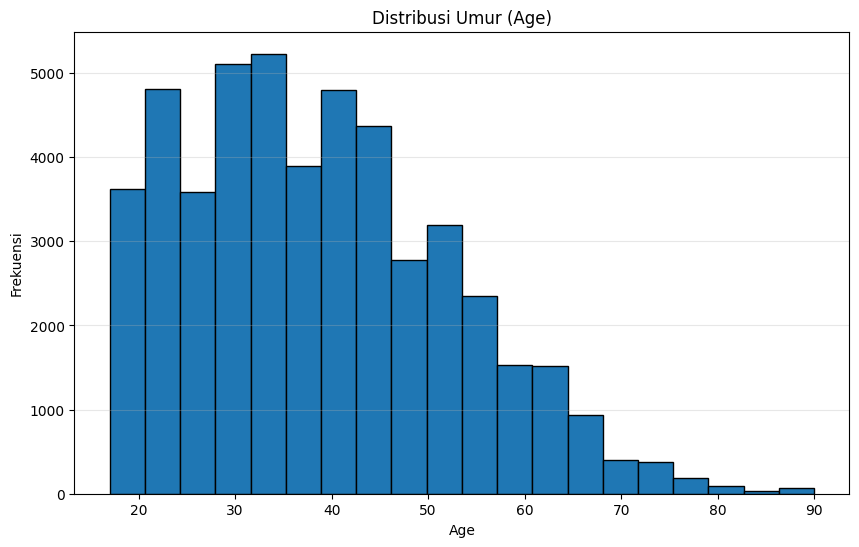

In [28]:
# Jawab 1.1 - Histrogram
plt.figure(figsize=(10, 6))

plt.hist(df["age"], bins=20, edgecolor="black")

plt.title("Distribusi Umur (Age)")
plt.xlabel("Age")
plt.ylabel("Frekuensi")
plt.grid(axis="y", alpha=0.3)

plt.show()

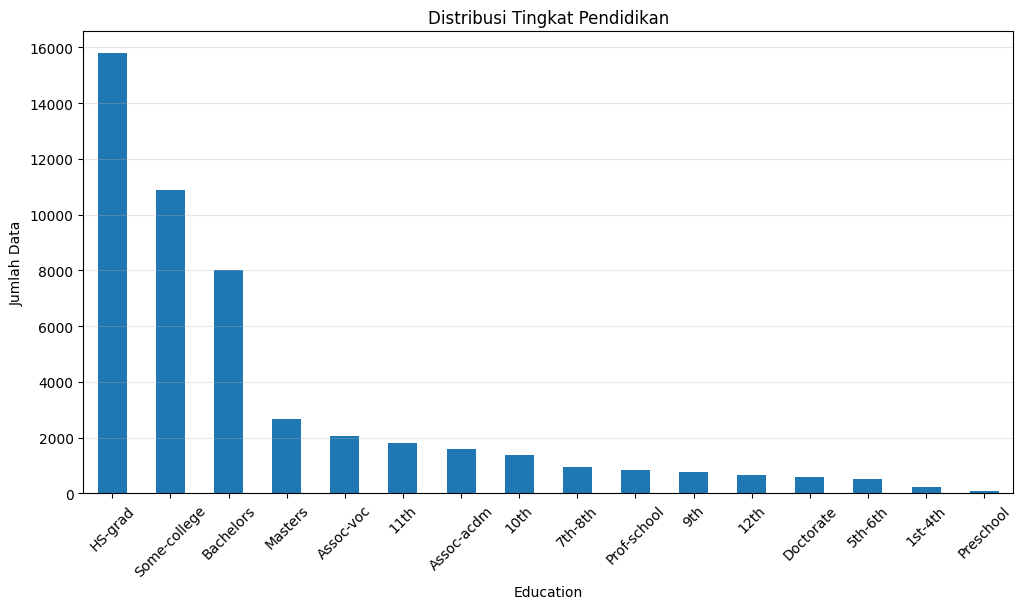

In [29]:
# Jawab 1.2 - Barchart
plt.figure(figsize=(12, 6))

education_counts = df["education"].value_counts()

education_counts.plot(kind="bar")

plt.title("Distribusi Tingkat Pendidikan")
plt.xlabel("Education")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

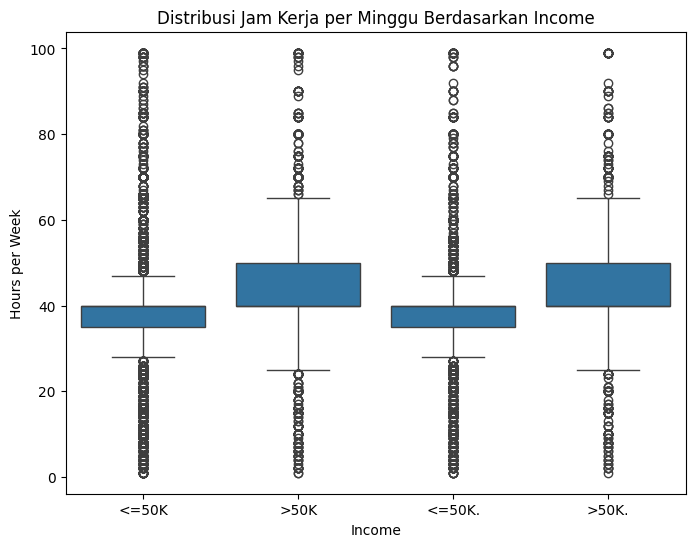

In [33]:
# Jawab 1.3 - Boxplot
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="income",
    y="hours-per-week"
)

plt.title("Distribusi Jam Kerja per Minggu Berdasarkan Income")
plt.xlabel("Income")
plt.ylabel("Hours per Week")

plt.show()

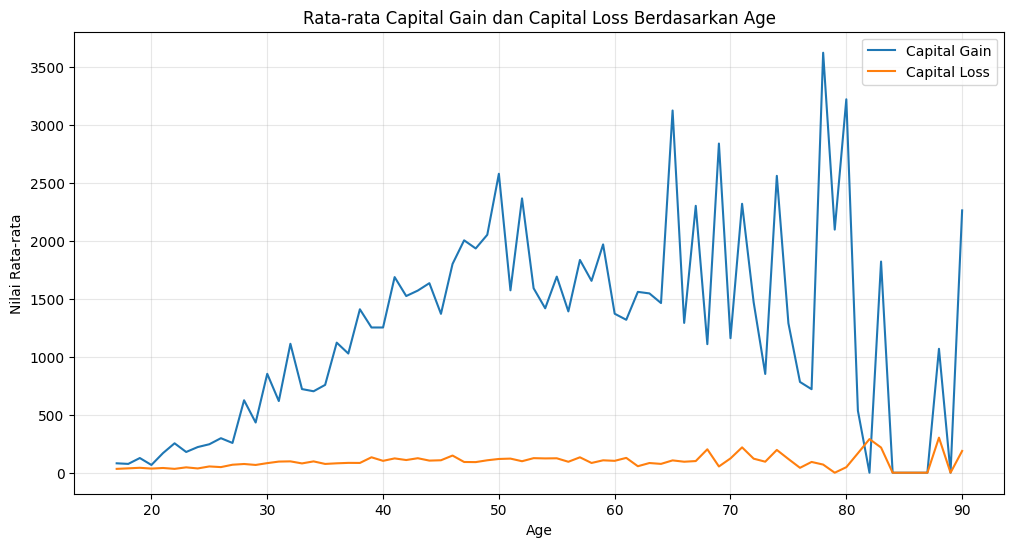

In [34]:
# Jawab 1.4 - Lineplot
plt.figure(figsize=(12, 6))

age_group = df.groupby("age")[["capital-gain", "capital-loss"]].mean()

plt.plot(
    age_group.index,
    age_group["capital-gain"],
    label="Capital Gain"
)

plt.plot(
    age_group.index,
    age_group["capital-loss"],
    label="Capital Loss"
)

plt.title("Rata-rata Capital Gain dan Capital Loss Berdasarkan Age")
plt.xlabel("Age")
plt.ylabel("Nilai Rata-rata")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [40]:
# Jawab dengan komentar python

# Jawaban Analisis Visual

'''
1. Distribusi data age:
Distribusi umur menunjukkan bahwa data lebih banyak terkonsentrasi
pada usia dewasa produktif. Frekuensi data pada usia muda hingga
usia menengah relatif lebih tinggi dibandingkan usia lanjut.
Distribusi ini cenderung tidak merata dan dapat memiliki kemencengan
(skewness) ke arah kanan karena terdapat sebagian kecil data dengan
usia yang lebih tinggi.

2. Strategi jika terdapat missing value pada variabel age:
Strategi yang digunakan adalah imputasi menggunakan median.
Median dipilih karena variabel age merupakan data numerik dan median
lebih tahan terhadap pengaruh outlier dibandingkan mean.
Dengan demikian, distribusi data tidak terlalu dipengaruhi oleh
nilai ekstrem.

3. Jumlah outlier pada setiap kategori income:
Outlier dihitung menggunakan metode IQR pada variabel hours-per-week
untuk setiap kelompok income. Kelompok income yang memiliki jumlah
outlier paling banyak dapat diketahui dari hasil perhitungan kode
berikut.
'''

# Menghitung jumlah outlier berdasarkan kategori income

def hitung_outlier(group):
    Q1 = group["hours-per-week"].quantile(0.25)
    Q3 = group["hours-per-week"].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    outlier = group[
        (group["hours-per-week"] < batas_bawah) |
        (group["hours-per-week"] > batas_atas)
    ]

    return len(outlier)

jumlah_outlier = df.groupby("income").apply(hitung_outlier)

print("Jumlah outlier setiap kategori income:")
print(jumlah_outlier)

print("\nKategori dengan outlier terbanyak:")
print(jumlah_outlier.idxmax())

Jumlah outlier setiap kategori income:
income
<=50K     7809
<=50K.    3897
>50K       510
>50K.      271
dtype: int64

Kategori dengan outlier terbanyak:
<=50K


/tmp/ipykernel_715/1408700062.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  jumlah_outlier = df.groupby("income").apply(hitung_outlier)


# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [41]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
from sklearn.preprocessing import LabelEncoder

# Membuat salinan dataframe
df_encoded = df.copy()

# Encoding kolom Sex
le_sex = LabelEncoder()
df_encoded["sex_encoded"] = le_sex.fit_transform(df_encoded["sex"])

# Encoding kolom Income
le_income = LabelEncoder()
df_encoded["income_encoded"] = le_income.fit_transform(df_encoded["income"])

# Menampilkan hasil encoding
display(
    df_encoded[
        ["sex", "sex_encoded", "income", "income_encoded"]
    ].head(10)
)

# Melihat mapping kategori
print("Mapping Sex:")
for kategori, nilai in zip(le_sex.classes_, le_sex.transform(le_sex.classes_)):
    print(kategori, "=", nilai)

print("\nMapping Income:")
for kategori, nilai in zip(le_income.classes_, le_income.transform(le_income.classes_)):
    print(kategori, "=", nilai)

,sex,sex_encoded,income,income_encoded
0,Male,1,<=50K,0
1,Male,1,<=50K,0
2,Male,1,<=50K,0
3,Male,1,<=50K,0
4,Female,0,<=50K,0
5,Female,0,<=50K,0
6,Female,0,<=50K,0
7,Male,1,>50K,2
8,Female,0,>50K,2
9,Male,1,>50K,2


Mapping Sex:
Female = 0
Male = 1

Mapping Income:
<=50K = 0
<=50K. = 1
>50K = 2
>50K. = 3


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

=== MATRiks KORELASI ===


,age,education-num,hours-per-week,capital-gain,capital-loss,income_encoded
age,1.000000,0.030940,0.071558,0.077229,0.056944,0.205173
education-num,0.030940,1.000000,0.143689,0.125146,0.080972,0.291074
hours-per-week,0.071558,0.143689,1.000000,0.082157,0.054467,0.198890
capital-gain,0.077229,0.125146,0.082157,1.000000,-0.031441,0.195755
capital-loss,0.056944,0.080972,0.054467,-0.031441,1.000000,0.129771
income_encoded,0.205173,0.291074,0.198890,0.195755,0.129771,1.000000


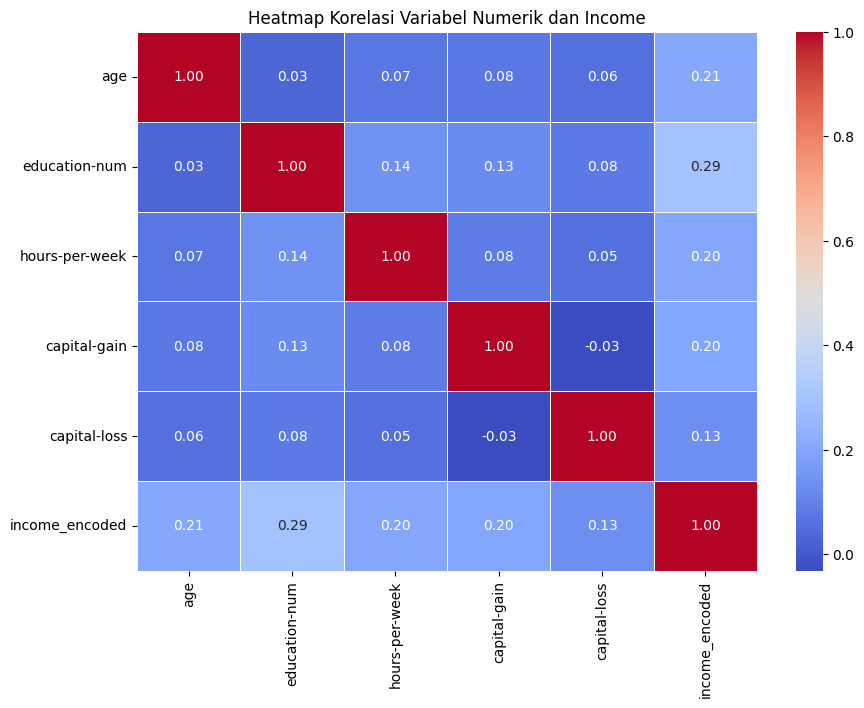

In [44]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
# Membuat dataframe untuk analisis korelasi
df_corr = df_encoded.copy()

# Memilih kolom yang diperlukan
kolom_korelasi = [
    "age",
    "education-num",
    "hours-per-week",
    "capital-gain",
    "capital-loss",
    "income_encoded"
]

# Menghitung matriks korelasi
correlation_matrix = df_corr[kolom_korelasi].corr()

print("=== MATRiks KORELASI ===")
display(correlation_matrix)

# Visualisasi heatmap:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap Korelasi Variabel Numerik dan Income")
plt.show()

In [45]:

# Hasil analisis korelasi

'''
Berdasarkan matriks korelasi, hubungan antarvariabel dapat dianalisis
berdasarkan nilai koefisien korelasi yang berada pada rentang -1 hingga 1.

Nilai korelasi positif menunjukkan bahwa ketika suatu variabel meningkat,
variabel lainnya cenderung ikut meningkat. Sebaliknya, nilai korelasi
negatif menunjukkan hubungan yang berlawanan arah.

Variabel education-num dapat digunakan untuk melihat hubungan antara
tingkat pendidikan dengan income. Jika nilai korelasinya positif,
maka semakin tinggi tingkat pendidikan, terdapat kecenderungan
income juga meningkat.

Variabel hours-per-week menunjukkan hubungan antara jumlah jam kerja
per minggu dengan income. Korelasi positif menunjukkan bahwa individu
dengan jam kerja lebih tinggi cenderung memiliki income yang lebih tinggi.

Capital-gain dan capital-loss dapat memiliki hubungan dengan income
karena kedua variabel tersebut berkaitan dengan keuntungan atau kerugian
finansial seseorang.

Age juga dapat menunjukkan hubungan dengan income, tetapi hubungan
tersebut tidak selalu kuat karena income dipengaruhi banyak faktor lain.

Korelasi tidak menunjukkan hubungan sebab-akibat, melainkan hanya
menunjukkan tingkat hubungan linear antarvariabel.
'''

'\nBerdasarkan matriks korelasi, hubungan antarvariabel dapat dianalisis\nberdasarkan nilai koefisien korelasi yang berada pada rentang -1 hingga 1.\n\nNilai korelasi positif menunjukkan bahwa ketika suatu variabel meningkat,\nvariabel lainnya cenderung ikut meningkat. Sebaliknya, nilai korelasi\nnegatif menunjukkan hubungan yang berlawanan arah.\n\nVariabel education-num dapat digunakan untuk melihat hubungan antara\ntingkat pendidikan dengan income. Jika nilai korelasinya positif,\nmaka semakin tinggi tingkat pendidikan, terdapat kecenderungan\nincome juga meningkat.\n\nVariabel hours-per-week menunjukkan hubungan antara jumlah jam kerja\nper minggu dengan income. Korelasi positif menunjukkan bahwa individu\ndengan jam kerja lebih tinggi cenderung memiliki income yang lebih tinggi.\n\nCapital-gain dan capital-loss dapat memiliki hubungan dengan income\nkarena kedua variabel tersebut berkaitan dengan keuntungan atau kerugian\nfinansial seseorang.\n\nAge juga dapat menunjukkan hubungan

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [18]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


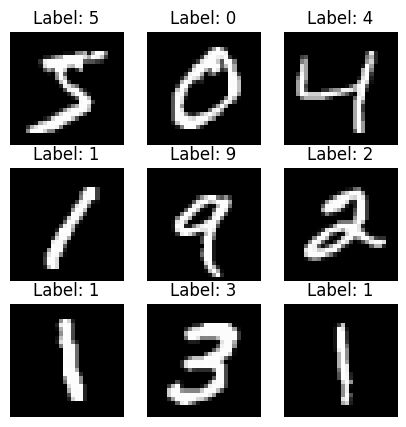

In [19]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

Shape sebelum resize: (10000, 28, 28)
Shape setelah resize: (10000, 32, 32)


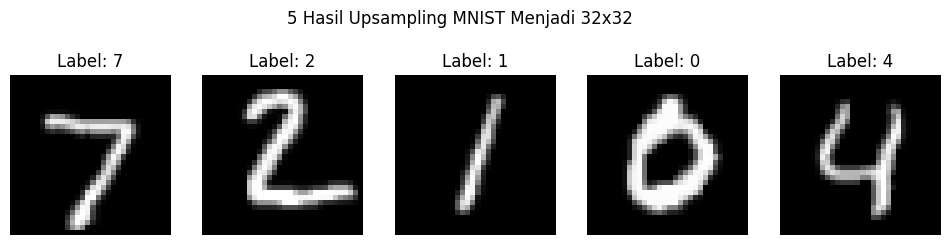

In [47]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Membuat array kosong untuk menyimpan hasil resize
X_test_resized = np.empty((X_test.shape[0], 32, 32), dtype=np.uint8)

# Proses upsampling setiap gambar dari 28x28 menjadi 32x32
for i in range(X_test.shape[0]):
    image = Image.fromarray(X_test[i])
    resized_image = image.resize((32, 32), Image.Resampling.BILINEAR)

    X_test_resized[i] = np.array(resized_image)

print("Shape sebelum resize:", X_test.shape)
print("Shape setelah resize:", X_test_resized.shape)

# Menampilkan 5 hasil upsampling:
plt.figure(figsize=(12, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_resized[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")

plt.suptitle("5 Hasil Upsampling MNIST Menjadi 32x32")
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

Nilai minimum: 0.0
Nilai maksimum: 1.0
Shape data: (10000, 32, 32)


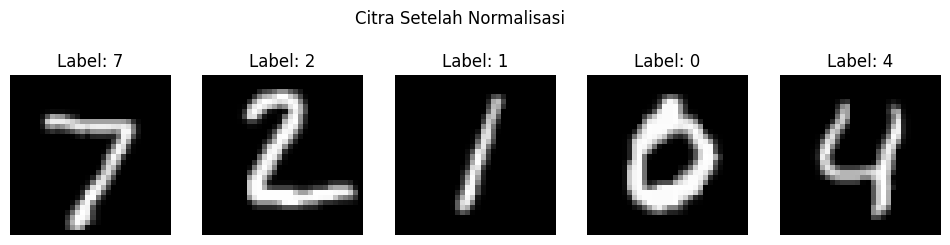

In [49]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
# Normalisasi nilai piksel dari 0-255 menjadi 0-1
X_test_normalized = X_test_resized.astype("float32") / 255.0

print("Nilai minimum:", X_test_normalized.min())
print("Nilai maksimum:", X_test_normalized.max())
print("Shape data:", X_test_normalized.shape)

# Menampilkan hasil normalisasi:
plt.figure(figsize=(12, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_normalized[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")

plt.suptitle("Citra Setelah Normalisasi")
plt.show()

Normalisasi dilakukan dengan membagi setiap nilai piksel dengan 255, sehingga seluruh nilai piksel berada pada rentang 0 sampai 1. Proses ini membantu model machine learning bekerja lebih stabil.

## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [50]:
# Jawab Soal 3
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
# Mengubah citra 32x32 menjadi array 1 dimensi
X_test_flatten = X_test_normalized.reshape(
    X_test_normalized.shape[0],
    32 * 32
)

print("Shape sebelum flatten:", X_test_normalized.shape)
print("Shape setelah flatten:", X_test_flatten.shape)

# Atau menggunakan flatten melalui reshape:
# Contoh melihat satu data setelah flatten
print("Jumlah fitur setiap gambar:", X_test_flatten.shape[1])
print("Data gambar pertama:")
print(X_test_flatten[0])

Shape sebelum flatten: (10000, 32, 32)
Shape setelah flatten: (10000, 1024)
Jumlah fitur setiap gambar: 1024
Data gambar pertama:
[0. 0. 0. ... 0. 0. 0.]


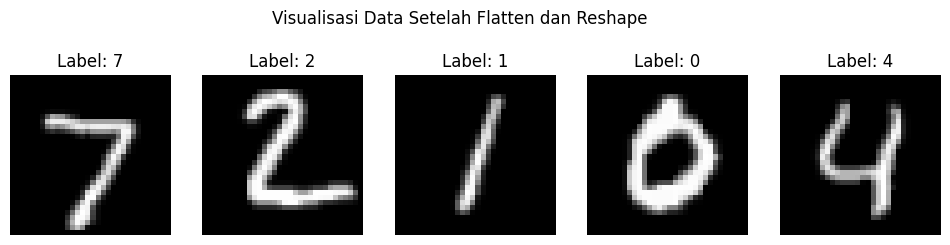

In [51]:
# Mengubah kembali data flatten menjadi bentuk gambar 32x32
X_test_reshape = X_test_flatten.reshape(-1, 32, 32)

plt.figure(figsize=(12, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_reshape[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")

plt.suptitle("Visualisasi Data Setelah Flatten dan Reshape")
plt.show()